<a href="https://colab.research.google.com/github/Prabhupritam-001/AML_LAB/blob/main/Experiment_03/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)


In [ ]:
df = pd.read_excel("https://raw.githubusercontent.com/Prabhupritam-001/AML_LAB/main/Experiment_03/cgpaPRED.xls")
df.columns

Index(['SEM 1', 'SEM 2', 'SEM 3', 'SEM 4', 'SEM 5'], dtype='object')

In [ ]:
df.head()

,SEM 1,SEM 2,SEM 3,SEM 4,SEM 5
0,6.60,7.60,6.90,7.22,7.08
1,7.77,7.22,7.00,7.90,7.47
2,6.90,6.00,7.12,7.54,6.89
3,5.50,6.60,6.70,6.50,6.33
4,7.20,6.00,7.21,7.70,7.03


In [ ]:
x = df.drop(columns=['SEM 5'])
y = df['SEM 5']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

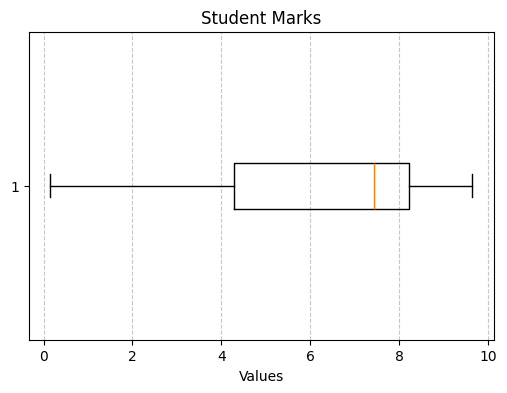

In [ ]:
plt.figure(figsize=(6, 4))
plt.boxplot(y, vert=False)
plt.title("Student Marks")
plt.xlabel("Values")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


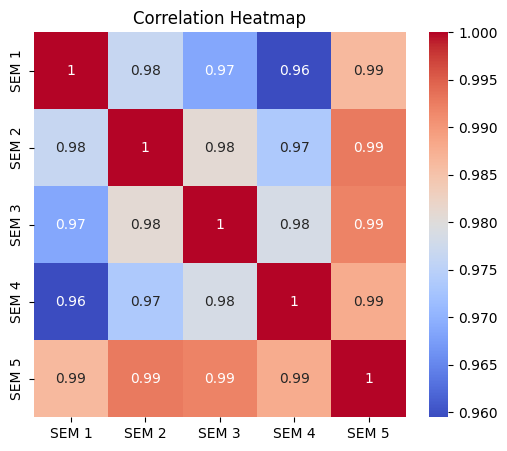

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
mlr = LinearRegression()
mlr.fit(x_train, y_train)

LinearRegression()

In [ ]:
y_pred = mlr.predict(x_test)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE  = {mse:.4f}")
print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R2   = {r2:.4f}")

MSE  = 0.0000
MAE  = 0.0023
RMSE = 0.0027
R2   = 1.0000


In [ ]:
print("\nEquation:")
print(f"SEM 5 = {mlr.intercept_:.4f}", end="")

for coef, col in zip(mlr.coef_, x.columns):
    print(f" + ({coef:.4f} * {col})", end="")
print()


Equation:
SEM 5 = 0.0036 + (0.2499 * SEM 1) + (0.2502 * SEM 2) + (0.2499 * SEM 3) + (0.2497 * SEM 4)


In [ ]:
ip = df[['SEM 1', 'SEM 2', 'SEM 3', 'SEM 4']].mean(axis=1).values.reshape(-1, 1)


In [ ]:
s_x_train, s_x_test, s_y_train, s_y_test = train_test_split(
    ip, y, test_size=0.2, random_state=42
)

In [ ]:
slr = LinearRegression()
slr.fit(s_x_train, s_y_train)

LinearRegression()

In [ ]:
s_y_pred = slr.predict(s_x_test)


In [ ]:
s_mse = mean_squared_error(s_y_test, s_y_pred)
s_mae = mean_absolute_error(s_y_test, s_y_pred)
s_rmse = root_mean_squared_error(s_y_test, s_y_pred)
s_r2 = r2_score(s_y_test, s_y_pred)

print(f"MSE  = {s_mse:.4f}")
print(f"MAE  = {s_mae:.4f}")
print(f"RMSE = {s_rmse:.4f}")
print(f"R2   = {s_r2:.4f}")

MSE  = 0.0000
MAE  = 0.0024
RMSE = 0.0027
R2   = 1.0000


In [ ]:
print("\nEquation:")
print(f"SEM 5 = {slr.intercept_:.4f} + ({slr.coef_[0]:.4f} x Average of SEM1-SEM4)")


Equation:
SEM 5 = 0.0035 + (0.9997 x Average of SEM1-SEM4)


In [ ]:
while True:
    user_choice = input("Do you want to predict SEM 5? (y/n): ").lower()

    if user_choice == "n":
        print("Goodbye")
        break
    elif user_choice == "y":
        s1 = float(input("Enter SEM 1: "))
        s2 = float(input("Enter SEM 2: "))
        s3 = float(input("Enter SEM 3: "))
        s4 = float(input("Enter SEM 4: "))

        pred = mlr.predict([[s1, s2, s3, s4]])
        print(f"Predicted SEM 5: {pred[0]:.2f}\n")
    else:

        print("Please enter 'y' or 'n'.\n")

Do you want to predict SEM 5? (y/n): n
Goodbye


In [ ]:
metrics=['MSE','MAE','RMSE','R2']
mvalues=[mse,mae,rmse,r2]
svalues=[s_mse,s_mae,s_rmse,s_r2]

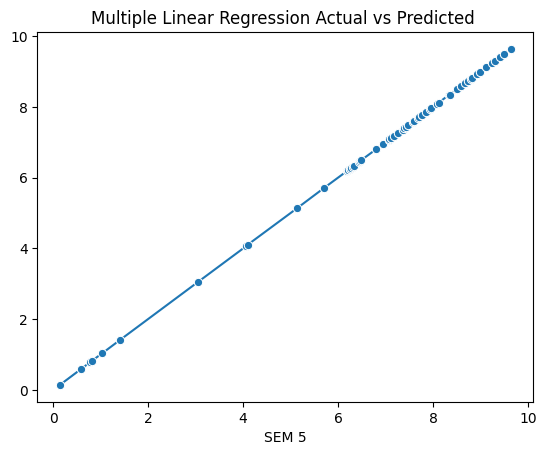

In [65]:
sns.lineplot(x=y_test,y=y_pred,marker='o')
plt.title("Multiple Linear Regression Actual vs Predicted ")
plt.show()

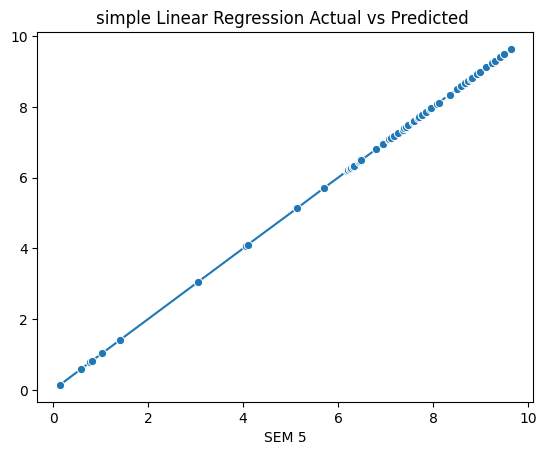

In [66]:
sns.lineplot(x=s_y_test,y=s_y_pred,marker='o')
plt.title("simple Linear Regression Actual vs Predicted ")
plt.show()

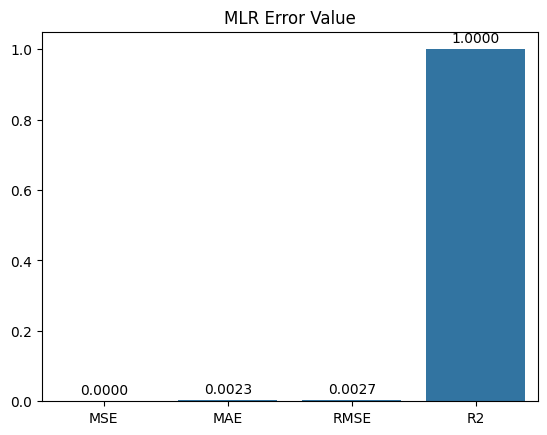

In [67]:
ax = sns.barplot(x=metrics, y=mvalues)
plt.title("MLR Error Value")
ax.bar_label(ax.containers[0], fmt="%.4f", padding=3)
plt.show()

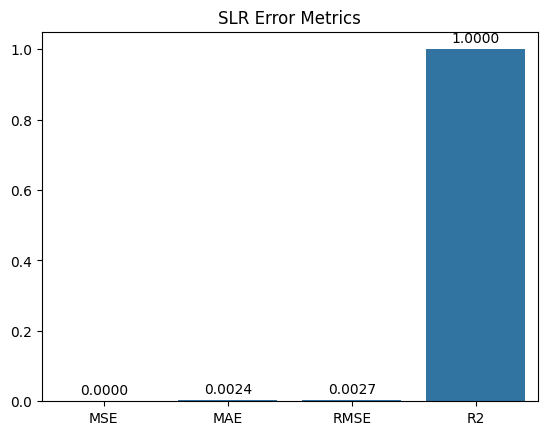

In [68]:
ax = sns.barplot(x=metrics, y=svalues)
plt.title("SLR Error Metrics")
ax.bar_label(ax.containers[0], fmt="%.4f", padding=3)
plt.show()